#### Note
This notebook was used for presentation during the Discriminants School at the MPI MiS, Leipzig, in 2025.
It was created by Lakshmi Ramesh and Nicolas Weiss.

#### References

The computation of volumes for semi algebraic CONVEX bodies has been discussed by 

- Lakshmi Ramesh, Nicolas Weiss: *"Exact volumes of semi-algebraic convex bodies"*, 2026.

it builds upon the algorithm originally described in:

- Pierre Lairez, Marc Mezzarobba, Mohab Safey El Din: *"Computing the volume of compact semi-algebraic sets"*, 2019.

A notebook implementing the volume computation for a torus can be found on Lairez's website at:

-  https://mathexp.eu/lairez/computing-with-integrals/   (Lecture 5)

#### Acknowledgement
We are greatly indebted to Eric Pichon-Pharabod for discussing extensively with us about the computational tools and theoretical background.

In [1]:
# With installation:
# import exact_convex_volumes

# Without installation:
from context import exact_convex_volumes

# In any case:
from exact_convex_volumes.volumes import *
from exact_convex_volumes.tools import *
from exact_convex_volumes.msolve_interface import *



# Computing volumes of L_p balls

Consider the unit ball in the $\ell_4$ norm. In the plot below you can find its boundary. The figure is also sometimes known as a "TV screen".

In [2]:
var('x,y')
f = 1 - (x^4 + y^4)

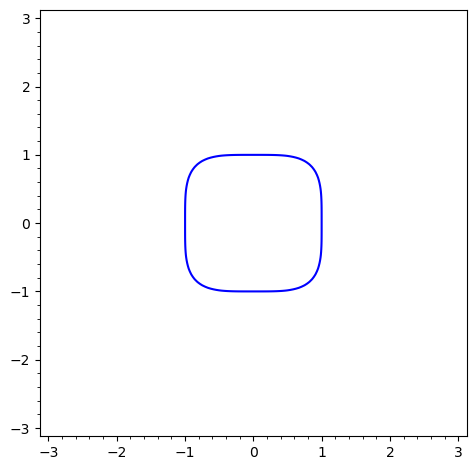

In [3]:
implicit_plot(f==0, (x,-3,3), (y,-3,3))

## Computation using Monte-Carlo approach

Let $U = \{f \geq 0 \}$ our $p$-ball. Let $X$ be a random variable uniformly distributed on $[-1,1]^2$.

$$\operatorname{Vol}(U) = \mathbb{E}\left[X \in U\right] \cdot \operatorname{Vol}([-1, 1]^2)$$

In [4]:
# Monte-Carlo computation:

from fractions import Fraction
import numpy as np

# Setup
n = 2
p = 4

# Number of samples and batch_size
num_samples = 200*1000*1000
batch_size =  1000000

# Region in which to sample:
radius_box = 1
center_box = 0

# Indicator function of the lp unit ball:
ind_funs = [lambda x_vec, mu=mu : np.sum(np.power(x_vec - np.array(mu), p), axis=1) <= 1 for mu in [[0,0],[1,0]]]

# Setup a random number generator:
seed = int(12345)
rng = np.random.default_rng(seed)

num_within_support = 0
for i in range(0, num_samples, batch_size):
    num_samples_batch = batch_size if (i + batch_size < num_samples) else num_samples - i 
    
    # Sample points
    sampled_points_batch = rng.uniform(-radius_box, radius_box, (num_samples_batch, n)) + center_box

    # Cancel out function by function the samples that are not in their support
    in_the_support_batch = np.full((num_samples_batch,), True)
    for ind_fun in ind_funs:
        # Check entries if previously or now not in the support of ind_fun
        in_the_support_batch &= ind_fun(sampled_points_batch)

    # apply indicator function to each entry and count 
    num_within_support_batch = np.count_nonzero(in_the_support_batch) 
    num_within_support += num_within_support_batch

# Return ratio of volume of box that corresponds to the support.
volume_mc =  num_within_support / num_samples * np.power(2 * radius_box, n)

print("Monte-Carlo approximated volume of Lp (p={}) unit ball in R^n (n={}): {:.100}".format(p, n, float(volume_mc)))



Monte-Carlo approximated volume of Lp (p=4) unit ball in R^n (n=2): 1.714595819999999992688799466122873127460479736328125


## Holonomic function approach

### The setup
Consider the projection map
$$\operatorname{pr}_x : U \rightarrow \mathbb{A}^1, \quad (x,y) \mapsto x$$
and denote the fiber of $U$ over $x$ by $U_x$.

Then the volume of $U$ can alternatively be described as
$$F(x) = \int^x_{-1}Vol(U_x)dx, \qquad \operatorname{Vol}(U) = F(1).$$

The magic of the holonomic function approach then lies in finding an operator $P \in \mathbb{Q}[x]\langle \partial_x\rangle$ which annihilates $F$, i.e. $P \bullet F = 0$. Then one can numerically (but with arbitrary precision) solve for $F$ via the theory of ODEs.


**Question:** How to find such an annihilating operator?


### Volume as a period

- TODO: Add note on how to obtain the period integral expression.

Our volume expression is therefore of the form $$\int_S h(x)dx$$ where $h(x)$ is in the field of fractions of the polynomial ring $\mathbb Z [x,y]$ and $S$ is a semialgebraic set. Such integrals converge to a real number, called a _period_. The integral is called a _period integral_. 

Since $\operatorname{vol}(U_x)$ is the period of the rational integral
$$\frac{1}{2 \pi i} \oint \frac{y}{f} \frac{\partial f}{\partial y} dy,$$ there is a differential operator $P$ that eliminates it.

Then by the FTOC $P \partial_x$ eliminates the function $F(x)$. 

In [5]:
from ore_algebra import *       # To deal with differential operators

In [6]:
R.<x,y> = PolynomialRing(QQ)    # QQ[x,y]
n = 2
p = 4
f = shifted_lp_poly(R,p,[0,0]);f

-x^4 - y^4 + 1

We know that the volume of $\{f \geq 0 \} \cap {pr}^{-1}_x$, for $V(f)$ smooth is a period of the rational integral $\int A(x,y)dy$
where $A(x,y) = \frac{y}{f}\frac{\partial f}{\partial y}$. (This is due to Stokes and Leray's residue theorem).

- TODO: Move this up.

In [7]:
proj_var = x
deform_value = 0
A = construct_integrand([f], deform_value, {}, proj_var); A

(-4*y^4)/(-x^4 - y^4 + 1)

### Creative telescoping

We can compute $P$ using a process called _creative telescoping_. 

The operator $P$, i.e. which annihilates this rational period integral $\int A dy$ and, therefore $\operatorname{Vol}(U_x)$ as a function of $x$ is called Picard-Fuchs operator:

In [8]:
# Picard-Fuchs operator
P = get_picard_fuchs([f], deform_value, {},proj_var); P

(-x^4 + 1)*Dx + x^3

Similarly then, the operator which annihilates $F(x) = \int^x_{-1} \operatorname{Vol}(U_x)dx$ is given by

In [9]:
Pdx = P*P.parent().gens()[0]; Pdx  # Observe: Singular locus are roots of x^4 - 1 (real roots are just +-1)

(-x^4 + 1)*Dx^2 + x^3*Dx

#### Solving the differential equation numerically

Let $P$ be a ordinary linear differential operator, then on any simply connected neighborhood $V$ outside the singular locus of $P$ we have
$$\dim \operatorname{Sol}(P)|_V = \operatorname{ord}(P).$$

So a solution on $V$ is uniquely determined by providing $\operatorname{ord}(P)$ many initial conditions. So if $\phi$ is the solution function we look for, we could provide the data of $\phi(z_0), \phi'(z_0), ..., \phi^{(\operatorname{ord})}(z_0)$. In practice, we only know how to interpret $\phi(z_0)$, resp. $\phi'(z_0)$ and have to provide the data at several points.


In [10]:
prec = 400  # binary digits of precision

Due to the symmetry in our example, compute the volume from $0$ to $1$ and double it.

Recall that we want to numerically solve $P\partial_x \bullet \phi = 0$ for $\phi$:

In [11]:
Pdx.local_basis_expansions(0)

[1, x]

In [12]:
# Initial Conditions
#var('u')
ini0 = [0, 2]    # This will correspond to \int_0^0 Vol(U_x), and Vol(U_0)


In [13]:
# The solution which is specified by the above initial conditions can be analytically continued to 1 
# and the coefs can be read off:
ini1 = Pdx.numerical_transition_matrix([0,1], eps=2^(-prec))*vector(ini0);

So the volume the L4 ball is given by:

In [14]:
VolL4 = 2 * ini1[0]; VolL4

[3.708149354602743836867700694390520092435197647043533811171856090112043553676239956714543723300743794555543742074919604745 +/- 1.45e-121] + [+/- 4.19e-134]*I

# Intersections of $\ell_p$ balls 

Now let $U$ be the intersection of two $\ell_4$ balls, one centred at $(0,0)$ and one centred at $(1,0)$. Then, setting $$f_1 = 1 - (x^4 + y^4)$$ and $$f_2 = 1 - ((x-1)^4 + y^4),$$ $U$ is defined as $$U = \{f_1 \geq 0 , f_2 \geq 0 \}.$$ 
We describe a new function $f$ as the product of $f_1, f_2$. 

In [15]:
R.<x,y> = QQ[]
SymRing = (x^2 +1).parent()
mus = [[0,0], [1,0]]
fs = [shifted_lp_poly(R, p, mu) for mu in mus]; fs

[-x^4 - y^4 + 1, -x^4 - y^4 + 4*x^3 - 6*x^2 + 4*x]

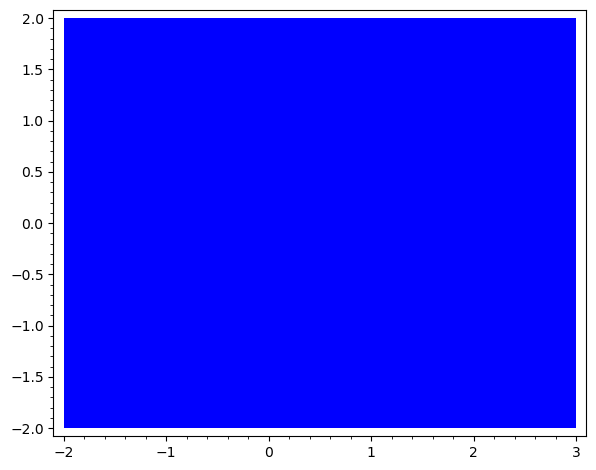

In [16]:
F = fs[0]*fs[1]
implicit_plot(SymRing(F)==0, (x,-2,3), (y,-2,2)) # Try from == 0 up to == 0.86.

### Deformation method

This is not smooth. So we deform our object by moving it away from the boundary by a parameter $t$. Our new function is then $f \in \mathbb Q[x,y,t]$ where $$f = f_1 \cdot f_2 - t$$


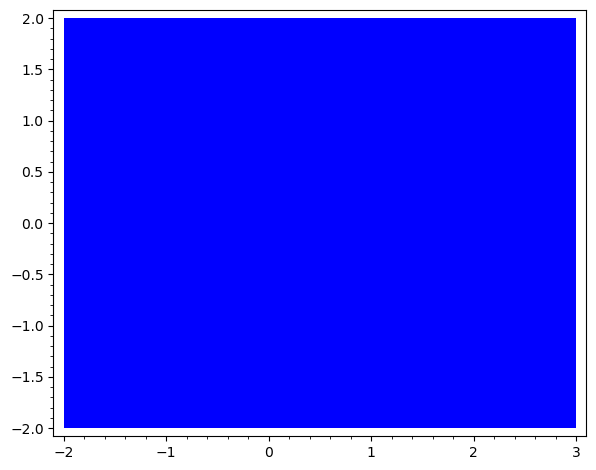

In [17]:
implicit_plot(SymRing(F) - 0.8==0, (x,-2,3), (y,-2,2))

We find the differential equation with respect to $t$, solve for the volume of the deformed slice $\operatorname{Vol}(U_t)$ and then using analytic continuation extend to $t=0$. The differential equation turns out to have order 6. This means we need 6 initial conditions!

In [18]:
# Consider the deformation. Will need to compute volumes of the deformed intersection for multiple t.
ft = deformed_product(fs, "t"); ft

-t + x^8 + 2*x^4*y^4 + y^8 - 4*x^7 - 4*x^3*y^4 + 6*x^6 + 6*x^2*y^4 - 4*x^5 - 4*x*y^4 - x^4 - y^4 + 4*x^3 - 6*x^2 + 4*x

In [19]:
At = construct_integrand_t(fs, "t"); At

(8*x^8 + 8*x^4*y^4 - 28*x^7 - 12*x^3*y^4 + 36*x^6 + 12*x^2*y^4 - 20*x^5 - 4*x*y^4 - 4*x^4 + 12*x^3 - 12*x^2 + 4*x)/(x^8 + 2*x^4*y^4 + y^8 - 4*x^7 - 4*x^3*y^4 + 6*x^6 + 6*x^2*y^4 - 4*x^5 - 4*x*y^4 - x^4 - y^4 + 4*x^3 - 6*x^2 + 4*x - t)

In [20]:
Pt = get_picard_fuchs_t(fs); Pt # Might take a while (~49 sec)
# Pt = (2372145315840000*t^18 - 90608723414015846400*t^17 - 1794178873123361384768*t^16 + 138436163143173506407344*t^15 - 259362145821415571999408*t^14 - 4261584408361701336063088*t^13 + 3032880839782520951721952*t^12 - 9353164788755871303602352*t^11 + 154672640299565837653480992*t^10 - 381586515280406109335552160*t^9 + 147092761458693043640367200*t^8 + 232175879282178134663220000*t^7 - 132409799060906025325760000*t^6 - 32778578100080258633600000*t^5 + 22603741634863463488000000*t^4 - 3554878468180070400000000*t^3 + 31004612904960000000000*t^2)*Dt^6 + (37954325053440000*t^17 - 1540362150052487308800*t^16 - 31765632114330540272624*t^15 + 2622317871835342869811620*t^14 - 6273155107987753500420108*t^13 - 58570491680701099141300036*t^12 - 102233109054071721165410020*t^11 - 32229024438662732900549688*t^10 + 2295283481403374990641765872*t^9 - 3723132521522206454731021920*t^8 - 289622816685110035499951400*t^7 + 2790060513591863325385860000*t^6 - 764945511198586378909600000*t^5 - 454414648180318539897600000*t^4 + 235525764542799283456000000*t^3 - 34812770665401753600000000*t^2 + 186027677429760000000000*t)*Dt^5 + (178289783009280000*t^16 - 7791587858146564500000*t^15 - 170685198337603428803289*t^14 + 14998436472247705616507787*t^13 - 43852401454184168142248088*t^12 - 251533613875724588722236564*t^11 - 1248579772343510647294912756*t^10 - 50269274078676082874402346*t^9 + 9382727590289345623105840224*t^8 - 7412433122004622574039079660*t^7 - 6551385841871736038206557600*t^6 + 7248214116966408032278020000*t^5 + 522787244219963428517600000*t^4 - 1738182880434865082131200000*t^3 + 632264094723919561728000000*t^2 - 82885221508935475200000000*t + 186027677429760000000000)*Dt^4 + (274855865241600000*t^15 - 13217433351636681782400*t^14 - 316616001572543996224356*t^13 + 29354387300630230871113164*t^12 - 102374367728141563280469276*t^11 - 417537505741473795083063790*t^10 - 3504494656382641146911465138*t^9 - 315425200647760892180306508*t^8 + 10929896144114843906338253472*t^7 - 425133944619160510222044840*t^6 - 9122432307579155118951162000*t^5 + 1614012451127830325515920000*t^4 + 3606650536850944363580800000*t^3 - 1943528551699088387481600000*t^2 + 449927818325067436032000000*t - 42210902261782118400000000)*Dt^3 + (111078999060480000*t^14 - 6125802706667274998400*t^13 - 168311958979661175627540*t^12 + 16216429067899715411806020*t^11 - 66998029195993258604929140*t^10 - 240827458919446425238420650*t^9 - 2596104446856704872602518442*t^8 + 20113408825993761598200168*t^7 + 2801593582654802924102955528*t^6 + 776714829291470403766479600*t^5 - 1552335875252035329909744000*t^4 - 2161007798281258860639360000*t^3 + 1342985924498795711078400000*t^2 - 410394435089645098598400000*t + 60584949861613240320000000)*Dt^2 + (4863721559040000*t^13 - 344511306057591187200*t^12 - 12054187667384875975680*t^11 + 1170693349489121540368200*t^10 - 5830073191078475002403400*t^9 - 20944201586664046977097200*t^8 - 271888887382062783961835280*t^7 + 152823391773534370404338400*t^6 + 398661814922563964092032000*t^5 - 9108078781342656778560000*t^4 - 92734478044097591001600000*t^3 - 65088395137703089152000000*t^2 + 50551902839446087680000000*t + 2684020452832051200000000)*Dt + 1029576960000*t^12 - 273705485512132800*t^11 - 21604418396005115520*t^10 + 1293836943002539757880*t^9 - 19673607350108134845720*t^8 - 312865401951479694288240*t^7 - 2076227624408145293485680*t^6 - 3021498663269383077084000*t^5 - 9269385478485531095520000*t^4 - 13510061483847521112000000*t^3 + 5501983026517236288000000*t^2 - 1103997374802717696000000*t + 502057362269952000000000

(2372145315840000*t^18 - 90608723414015846400*t^17 - 1794178873123361384768*t^16 + 138436163143173506407344*t^15 - 259362145821415571999408*t^14 - 4261584408361701336063088*t^13 + 3032880839782520951721952*t^12 - 9353164788755871303602352*t^11 + 154672640299565837653480992*t^10 - 381586515280406109335552160*t^9 + 147092761458693043640367200*t^8 + 232175879282178134663220000*t^7 - 132409799060906025325760000*t^6 - 32778578100080258633600000*t^5 + 22603741634863463488000000*t^4 - 3554878468180070400000000*t^3 + 31004612904960000000000*t^2)*Dt^6 + (37954325053440000*t^17 - 1540362150052487308800*t^16 - 31765632114330540272624*t^15 + 2622317871835342869811620*t^14 - 6273155107987753500420108*t^13 - 58570491680701099141300036*t^12 - 102233109054071721165410020*t^11 - 32229024438662732900549688*t^10 + 2295283481403374990641765872*t^9 - 3723132521522206454731021920*t^8 - 289622816685110035499951400*t^7 + 2790060513591863325385860000*t^6 - 764945511198586378909600000*t^5 - 45441464818031853989

In [21]:
Pt.order()

6

So we will need 6 initial conditions! (i.e. volumes of the deformed intersections)

### Computation of the volumes for the slices (in compact form)

There are no critical values of $pr_t : V(f(t,x,y)) \rightarrow \mathbb{A}^1$ for small $t >0$.

So we can compute the volumes of the deformations for small $t$'s all in the same way:

In [22]:

# Define volume computation for small 1 >> t > 0   (smaller than the branch point of Pt)
def vol_t_deformation(t0):
    # The deformed poly
    fdef = eval_poly(deformed_product(fs), [t0])

    # The picard fuchs operator of the deformed set (when projected onto the x-axis.)
    proj_var = x
    deq = get_picard_fuchs(fs,t0,{},proj_var)                       # Annihilates Vol_1(fiber(x))
    deqi = deq * deq.parent().gens()[0]        # Annihilates \int^x_0 Vol_1(fiber(x))

    # Compute the critical values of the projection onto x (using the symmetry)    // DRAW THIS
    # TODO: Here the exact value is important, i.e. to identify the boundary points in the set of singular points of the picard fuchs operator.
    branchpoints = partial_eval_poly(fdef, {y:0}).roots(AA, multiplicities=False)
    bdry_xs = [branchpoints[1], branchpoints[2]]
    #bdry_xs = [pt[x] for pt in project_deformed_intersection(fs, t0, proj_var, {}, prec)]
    #bdry_xs.sort()

    # INITIAL CONDITIONS (vol of 1-dimensional fibers)
    ## The operator in this case will have order 3.
    
    # Compute the 1 dim fiber (length) over 1/2
    x0 = QQ(1/2)
    volFiber_x0 = get_1_dim_volume(fs, {x:x0}, t0, prec)

    # Compute the 1 dim fiber at point to the right
    x1 = QQ(1/2 + 1/100)
    volFiber_x1 = get_1_dim_volume(fs, {x:x1}, t0, prec)

    # Set up the initial conditions
    var('u')
    # At 0:
    ini0 = [0, volFiber_x0, u]
    # At 1: Here this will depend on u -> Linear eq. in u =  volFiber_x1:
    ini1 = deqi.numerical_transition_matrix([x0, x1], eps=2^(-prec))*vector(ini0)
    
    solu = (volFiber_x1-ini1[1](u=0))/ini1[1].diff(u)

    # Now analytically continue to the boundary point, read of the coef of $1$.
    ini_boundary = deqi.numerical_transition_matrix([x0, bdry_xs[1]], eps=2^(-prec), assume_analytic=True)*vector(ini0);
    volume = 2*ini_boundary[0](u=solu)

    return volume

Compute the volumes of the deformations. They will serve as initial conditions to the order $6$ differential equation ($Pt \bullet \phi = 0$):

In [23]:
#maxt = QQ[t](Pt.leading_coefficient()).roots(QQbar, multiplicities=False)[3]  # First singularity to avoid after 0
ts = [1/1000, 2/1000, 3/1000, 4/1000, 5/1000, 6/1000];ts[0].parent()
vols = [vol_t_deformation(ti) for ti in ts]; vols

[[1.71029721953580885276843168336326725828271150175254242231964528799289191475293936856045848982021761095191389007905946 +/- 4.16e-117] + [+/- 1.14e-134]*I,
 [1.70681055216020583539199189026961858666599518984811980672811520502014276679480849992839882412432734238253609381033151 +/- 7.19e-117] + [+/- 2.60e-128]*I,
 [1.70357703107301987796897689965773735996559062219263949396697237286523676491394278783869539429798490748913588981621140 +/- 4.58e-117] + [+/- 1.24e-130]*I,
 [1.70050372900156217006689523027863414320142964340941601663277783781370894808939061598619738950494661887109278928616331 +/- 5.61e-117] + [+/- 1.62e-126]*I,
 [1.69754707107434645107838891474484934917998722345193953563011326612020737704980661261406486243832775460038384237948824 +/- 4.17e-117] + [+/- 2.12e-127]*I,
 [1.69468167327353423089162180971816024720056968159566087643627063464124973758628726085687121897624924472618209122503008 +/- 3.93e-117] + [+/- 3.60e-126]*I]

Now solve the picard fuchs operator for $\operatorname{Vol}(U_t)$, i.e. in terms of the initial conditions $\phi(t_i) = \operatorname{Vol}(U(t_i))$.

In [24]:
# Pt.local_basis_expansions(ts[0])

var('b,c,d,e,f')
ini_ts0 = [vols[0], b,c,d,e,f]

# Transition to the five other points and yields linear equations in b,c,d,e,f:
lin_eqs = [(Pt.numerical_transition_matrix([ts[0], ts[i]], eps=2^(-prec))*vector(ini_ts0))[0] for i in range(1, len(vols))]; 

In [25]:
constant_terms = vector([v.subs(b=0,c=0,d=0,e=0,f=0) for v in lin_eqs])

In [26]:
CB = ComplexBallField(prec)
# Express in terms of matrices
M = matrix([[coef.coefficient(v) for v in [b,c,d,e,f] ] for coef in lin_eqs])
M.change_ring(CB).inverse()

v = vector(vols[1:]).change_ring(CB); v.parent();

# Solve
Minv_v = M.inverse() * (v-constant_terms); Minv_v

([-3.6769574324653383201221909820914197746939170510615172133915856396395465619297345943803544240857891109740 +/- 4.83e-104] + [+/- 1.68e-122]*I, [248.7330688278300120316597139445085274043151105045803928687985447819802484356996629656998845695544293207 +/- 4.54e-101] + [+/- 4.33e-119]*I, [-85919.8812451467244106543815774276443490823515220875031504211335526023876965724192260759933703661078446 +/- 6.35e-98] + [+/- 4.83e-116]*I, [43293324.5859985634887438647291338308457340359045570139480460073628690216019264005853340303958813676006 +/- 7.49e-95] + [+/- 3.68e-113]*I, [-26057518310.7463241262385958203951729137868204530354708318021120018652897505754636710960881824184058033 +/- 5.11e-92] + [+/- 2.56e-110]*I)

Plug in the result and analytically continue to $t=0$ to read off the volume of the intersection.

In [27]:
ini_0 = Pt.numerical_transition_matrix([ts[0], 0], eps=2^(-prec))*vector(ini_ts0)
Vol_0 = ini_0[0](b=Minv_v[0], c=Minv_v[1], d= Minv_v[2], e=Minv_v[3], f=Minv_v[4]); Vol_0

[1.714482859044855236241617456389863266850907891292196002387016141008363973273758352945472686246402767128127 +/- 4.93e-106] + [+/- 3.74e-124]*I

**Note:** The computed volume can also directly be computed via our package:

In [28]:
vol = volume2(fs, prec=200, debug_level=1)
print("Computed volume:", vol)

[Vol2] Start of volume2:
[Vol2] fs = [-x^4 - y^4 + 1, -x^4 - y^4 + 4*x^3 - 6*x^2 + 4*x]
[CT] Entering creative telescoping:

[CT] Integrating out the variable Dx

[CT] Integrating out the variable Dy
[Vol2] Pt = 
[Vol2] order(Pt) = 6

Restarting with another random linear form
Restarting with a non-random linear form[Vol2] Lead coef = 2372145315840000*t^18 - 90608723414015846400*t^17 - 1794178873123361384768*t^16 + 138436163143173506407344*t^15 - 259362145821415571999408*t^14 - 4261584408361701336063088*t^13 + 3032880839782520951721952*t^12 - 9353164788755871303602352*t^11 + 154672640299565837653480992*t^10 - 381586515280406109335552160*t^9 + 147092761458693043640367200*t^8 + 232175879282178134663220000*t^7 - 132409799060906025325760000*t^6 - 32778578100080258633600000*t^5 + 22603741634863463488000000*t^4 - 3554878468180070400000000*t^3 + 31004612904960000000000*t^2
[Vol2] Singular Locus = [[38216.704318830307325042052035744959592823597471165700195372 +/- 2.19e-55], [28.426208095641635

In [29]:
vol

[1.7144828590448552362416174563898632668509 +/- 9.01e-41] + [+/- 3.76e-51]*I